# Qiskit 101 — Lab 00
## Getting Started with Qiskit in Google Colab

### Learning Objectives

By the end of this laboratory, you should be able to:

1. Set up Qiskit in Google Colab.
2. Create a quantum circuit using `QuantumCircuit`.
3. Apply Hadamard and CNOT gates.
4. Create a two-qubit Bell state.
5. Measure a quantum circuit.
6. Execute a circuit using `StatevectorSampler`.
7. Visualize measurement results.
8. Experimentally investigate the role of the Hadamard gate.

### Learning Approach

Throughout this notebook, use the following cycle:

**Predict → Build → Execute → Observe → Explain**

Whenever you see a **Predict** question, try to answer it before executing the next code cell.

## 1. Install Qiskit

Google Colab provides a ready-to-use Python environment, but Qiskit is not installed by default.

The following command installs **Qiskit** together with its visualization dependencies.

- `%pip` installs a Python package within the current Colab environment.
- `qiskit[visualization]` also installs packages required for circuit drawings and plots.
- The `-q` option performs the installation in quiet mode, reducing unnecessary installation messages.

> **Note:** You normally need to run this installation cell each time you start a new Colab runtime.




In [ ]:
%pip install -q "qiskit[visualization]"

## 2. Verify the Qiskit Installation

Before creating quantum circuits, let us confirm that Qiskit has been installed correctly.

The following code:

1. imports the `qiskit` package, and
2. displays the installed Qiskit version.

If the cell executes without an error and prints a version number, the Qiskit environment is ready.

In [ ]:
import qiskit

print("Qiskit version:", qiskit.__version__)

Qiskit version: 2.5.2


## 3. Create Our First Quantum Circuit

We will now create a quantum circuit containing **two qubits**.

Both qubits initially start in the state

\[
|00\rangle.
\]

We then perform two operations:

1. `h(0)` applies a **Hadamard (H) gate** to qubit 0. It places the first qubit into an equal superposition of 0 and 1.
2. `cx(0,1)` applies a **controlled-X (CNOT) gate**. Qubit 0 is the control and qubit 1 is the target.

Together, these operations prepare the Bell state

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
\]

Finally, `qc.draw("mpl")` displays the circuit graphically.

### Think before running

What measurement outcomes would you expect from this circuit: `00`, `01`, `10`, `11`, or some combination?

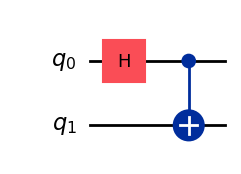

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.draw("mpl")

## 4. Measure the Qubits

A quantum state cannot be directly observed. To obtain classical information from the circuit, we must **measure the qubits**.

`measure_all()` adds a measurement operation to every qubit and automatically creates the required classical bits.

For the Bell state, an ideal measurement should produce only:

- `00`, or
- `11`.

Each should occur with approximately **50% probability**.

The individual outcome of any one execution is unpredictable, but the two qubits are perfectly correlated.

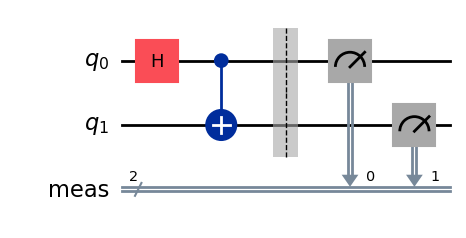

In [ ]:
qc.measure_all()

qc.draw("mpl")

## Background: What is `StatevectorSampler`?

So far, we have **constructed a quantum circuit**, but constructing a circuit does not execute it. To study its behavior, we need a way to run the circuit and obtain measurement results.

In this laboratory, we use Qiskit's **`StatevectorSampler`**.

### What does `StatevectorSampler` do?

`StatevectorSampler` is a Qiskit **simulation-based primitive** that executes quantum circuits locally using their ideal quantum state and samples measurement outcomes from that state.

It does **not require access to a physical quantum computer**.

Conceptually, our workflow is:

**Quantum Circuit → Statevector Simulation → Measurement Sampling → Classical Results**

For example, our Bell-state circuit prepares the quantum state

$$
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
$$

The corresponding theoretical measurement probabilities are

$$
P(00)=\frac{1}{2},
\qquad
P(11)=\frac{1}{2}.
$$

`StatevectorSampler` uses these probabilities to simulate repeated measurements of the circuit.

---

### What is a Shot?

A **shot** represents one simulated execution and measurement of the quantum circuit.

When we specify

```python
shots = 1024
```

we are asking the sampler to perform the measurement experiment **1,024 times**.

Therefore, we may obtain results such as:

```text
00 : 510
11 : 514
```

Running the experiment again may produce slightly different counts:

```text
00 : 497
11 : 527
```

This variation is expected because quantum measurement is probabilistic.

As the number of shots increases, the observed relative frequencies generally approach the theoretical probabilities.

---

### Why Use `StatevectorSampler`?

`StatevectorSampler` is useful while learning Qiskit because it allows us to:

* execute quantum circuits locally;
* experiment without waiting for quantum hardware;
* study ideal quantum behavior;
* obtain measurement samples using a specified number of shots;
* compare theoretical probabilities with observed frequencies; and
* establish an ideal reference before studying noise and real quantum hardware.

---

### `StatevectorSampler` vs. a Real Quantum Computer

| StatevectorSampler                           | Real Quantum Hardware                       |
| -------------------------------------------- | ------------------------------------------- |
| Runs locally                                 | Runs on a physical QPU                      |
| Uses mathematical simulation                 | Uses physical qubits                        |
| Represents ideal circuit behavior by default | Subject to hardware noise and imperfections |
| No IBM Quantum hardware access required      | Requires access to quantum hardware         |
| Useful for learning and testing              | Useful for real quantum experiments         |

Later, we can execute similar circuits on **IBM Quantum hardware** and compare the hardware results with the ideal results obtained using `StatevectorSampler`.

---

### In Our Program

We first create the sampler:

```python
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()
```

We then ask it to execute our circuit:

```python
job = sampler.run([qc], shots=1024)
```

and retrieve the result:

```python
result = job.result()
```

Finally, we obtain the measurement counts:

```python
counts = result[0].data.meas.get_counts()
```

Thus, the complete idea is:

> **Build the quantum circuit → simulate its quantum evolution → sample the measurements → analyze the classical outcomes**

### Key Takeaway

> **`StatevectorSampler` allows us to study how an ideal quantum circuit behaves by simulating its state and sampling measurement outcomes without requiring a physical quantum computer.**


## 5. Execute the Circuit

Now we execute the measured circuit using Qiskit's `StatevectorSampler`.

A **shot** represents one execution and measurement of the quantum circuit. We use:

`shots = 1024`

so the experiment is repeated 1,024 times.

The sampler returns the measurement results, and `get_counts()` counts how many times each bit string occurred.

For an ideal Bell-state circuit, we expect approximately:

`00 → 50%`

`11 → 50%`

The exact numbers will vary from one execution to another because quantum measurement is probabilistic.

### Question

Why do we expect `00` and `11`, but not `01` and `10`?

In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([qc], shots=1024)
result = job.result()

counts = result[0].data.meas.get_counts()

print(counts)

{'00': 512, '11': 512}


## 6. Visualize the Measurement Results

A histogram provides an intuitive way to examine the measurement distribution.

`plot_histogram(counts)` plots the number of occurrences of each measured bit string.

For our Bell-state circuit, the histogram should show two approximately equal bars corresponding to `00` and `11`.

### Observe

Are the two bars exactly equal?

If not, why might they differ slightly even though the theoretical probabilities are both 50%?

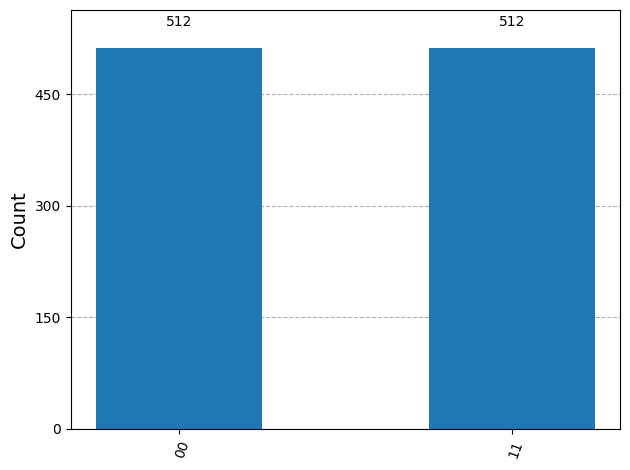

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

# Exercises — Explore the Circuit

You have successfully created and executed your first quantum circuit. Now modify the circuit to investigate how individual quantum operations and experimental parameters affect the results.

For each exercise, follow this learning cycle:

> **Predict → Modify → Execute → Observe → Explain**

**Important:** Write down your prediction **before running the modified circuit**.

---

## Exercise 1 — Remove the Hadamard Gate

Start with the Bell-state circuit:

```python
qc.h(0)
qc.cx(0, 1)
```

Remove the Hadamard gate `h(0)` but retain the CNOT gate.

### Predict

Before executing the circuit, answer:

1. What is the initial state of the two qubits?
2. What is the value of the CNOT control qubit?
3. Will the CNOT gate flip the target qubit?
4. Which measurement outcomes do you expect?
5. Will the result still be probabilistic?

Now execute the modified circuit with **1024 shots** and compare the observed result with your prediction.

### Explain

Why does removing the H gate change the Bell-state measurement distribution?

---

## Exercise 2 — Remove the CNOT Gate

Restore the Hadamard gate but remove the CNOT gate.

The circuit should now contain only:

```python
qc.h(0)
```

### Predict

Before running the circuit, determine:

1. What state does the H gate create for qubit 0?
2. What happens to qubit 1?
3. Which two-bit measurement outcomes do you expect?
4. What approximate probabilities do you expect for those outcomes?
5. Are the two qubits now entangled?

Execute the circuit and compare the results with the original Bell-state circuit.

### Explain

Why is the Hadamard gate alone insufficient to create the Bell state?

---

## Exercise 3 — Investigate the Number of Shots

Return to the original Bell-state circuit:

```python
qc.h(0)
qc.cx(0, 1)
```

Run exactly the same circuit using different numbers of shots:

```text
100 shots
1,024 shots
10,000 shots
```

Record your observations.

|  Shots | Count of 00 | Count of 11 | % of 00 | % of 11 |
| -----: | ----------: | ----------: | ------: | ------: |
|    100 |             |             |         |         |
|  1,024 |             |             |         |         |
| 10,000 |             |             |         |         |

### Think

1. Are the counts of `00` and `11` exactly equal?
2. Which experiment gives frequencies closest to 50%–50%?
3. Why do the measured frequencies change when you repeat the experiment?
4. Does increasing the number of shots change the quantum state itself?

### Key Question

What is the difference between a **theoretical probability** and an **experimentally observed frequency**?

---

## Exercise 4 — Apply X Before CNOT

Create a new two-qubit circuit and apply an X gate to qubit 0 before applying CNOT:

```python
qc.x(0)
qc.cx(0, 1)
```

Remember that the X gate performs the quantum equivalent of a bit flip:

$$
X|0\rangle = |1\rangle
$$

### Predict

Starting from \(|00\rangle\):

1. What state is produced after `x(0)`?
2. What is now the value of the CNOT control qubit?
3. Will CNOT flip qubit 1?
4. What final two-qubit state do you predict?
5. What measurement result should appear after 1024 shots?

Execute the circuit and verify your reasoning.

### Compare

Compare this experiment with Exercise 1:

* **Exercise 1:** CNOT with control qubit initially `0`
* **Exercise 4:** CNOT with control qubit changed to `1`

What does this demonstrate about the operation of a controlled gate?

---

# Reflection

After completing all four exercises, answer the following questions in your own words:

1. What role does the **Hadamard gate** play in the Bell-state circuit?
2. What role does the **CNOT gate** play?
3. Why does CNOT applied directly to \(|00\rangle\) produce `00`?
4. Why does applying X before CNOT produce a different result?
5. Why are Bell-state measurement results probabilistic even though the circuit is fixed?
6. Why do experimental frequencies approach theoretical probabilities as the number of shots increases?
7. What is the difference between **superposition** and **entanglement**?

## Challenge

Without executing Qiskit, predict the measurement distribution of the following circuit:

```python
qc = QuantumCircuit(2)
qc.x(0)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
```

Write your prediction first. Then execute the circuit and determine whether your reasoning was correct.

---

### Lab 00 Competency Check

After completing this laboratory, you should be able to say:

> **I can construct, modify, execute, and interpret simple Qiskit circuits, and I can explain how H, X, CNOT, measurement, and the number of shots affect the observed results.**


# Experiment 1: What Happens If We Remove the Hadamard Gate?

We previously used two gates to prepare the Bell state:

**H → CNOT**

Let us investigate the role of the Hadamard gate.

We will create a new two-qubit circuit but **remove the H gate**, leaving only the CNOT operation.

Remember that both qubits initially start in

\[
|00\rangle.
\]

A CNOT flips its target qubit only when its control qubit is `1`.

### Predict before running

The control qubit is initially `0`.

What do you think the final state will be?

- `00`
- `01`
- `10`
- `11`
- a probabilistic combination

Write down your prediction before executing the circuit.

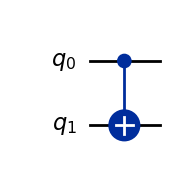

In [ ]:
qc = QuantumCircuit(2)


qc.cx(0, 1)

qc.draw("mpl")

## Measure the Modified Circuit

We now add measurements to the circuit containing only the CNOT gate.

Before executing it, trace the circuit logically:

1. Initial state: `00`
2. Control qubit q0 = `0`
3. CNOT changes its target only if the control is `1`
4. Therefore, does the CNOT change the state?

Run the cell to add the measurements and inspect the resulting circuit.

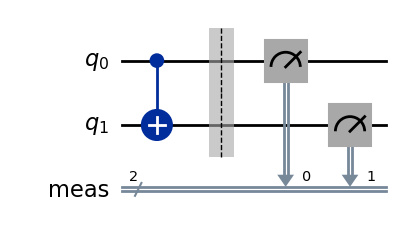

In [ ]:
qc.measure_all()

qc.draw("mpl")

## Execute the Modified Circuit

We will again execute the circuit 1,024 times using `StatevectorSampler`.

Compare this result with the previous Bell-state experiment.

### Expected reasoning

Without the Hadamard gate, qubit 0 remains in state `0`.

Because the CNOT control is `0`, the CNOT does not flip qubit 1.

Therefore,

\[
|00\rangle \xrightarrow{CNOT} |00\rangle.
\]

### Prediction

We should therefore obtain `00` in every shot on an ideal simulator.

Run the experiment and check whether your prediction is correct.

In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([qc], shots=1024)
result = job.result()

counts = result[0].data.meas.get_counts()

print(counts)


{'00': 1024}


## Visualize the Modified Result

Plot the measurement results for the modified circuit.

Compare this histogram with the Bell-state histogram from the previous experiment.

### What did we learn?

With the Hadamard gate:

\[
|00\rangle
\rightarrow
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\rightarrow
\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
\]

Without the Hadamard gate:

\[
|00\rangle
\rightarrow
|00\rangle.
\]

Therefore, **CNOT alone does not create entanglement from the initial state `|00⟩`**.

The Hadamard gate first creates superposition. The CNOT then acts on that superposition to produce the entangled Bell state.

### Key takeaway

> **H creates the required superposition; CNOT converts the resulting two-qubit state into an entangled Bell state.**

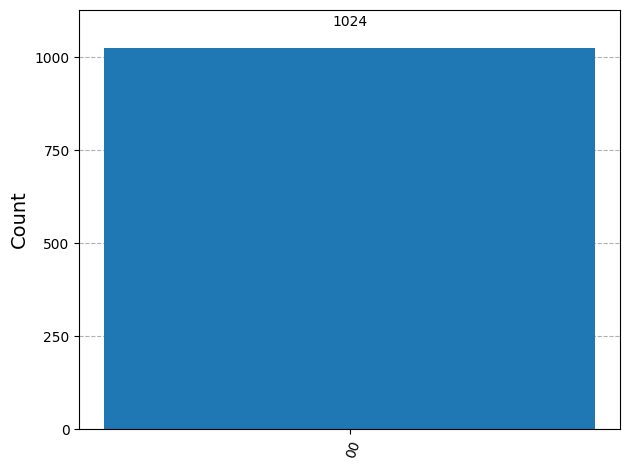

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)
